# 05 Evaluate Human Annotations: Two-Annotator Reliability and Model Evaluation

Dieses Notebook wertet die finale Human Evaluation mit **zwei menschlichen Annotator:innen** aus:

- `human_evaluation_ai_2_annotators.csv`
- `human_evaluation_real_2_annotators.csv`

Die zentrale Einheit ist ein Video-Modellbereich-Paar, das von Annotator 1 und Annotator 2 bewertet wurde. Wissenschaftlich wichtig ist daher eine Trennung zwischen:

1. **Interrater-Reliabilität**: Stimmen die beiden menschlichen Annotationen hinreichend überein?
2. **Konsensbasierte Modellbewertung**: Wie gut wurden die Modellannotationen bewertet, nachdem die zwei menschlichen Ratings pro Item zusammengeführt wurden?

Die `eval_*`-Spalten sind ordinale 1-5-Ratings zur Passung der Modellannotation zum Video. `Unbestimmt` wird als **nicht anwendbar / nicht beurteilbar** behandelt, nicht als schlechtes Rating. Für ordinale Ratings werden deshalb vor allem **quadratisch gewichtetes Cohen's Kappa**, **Exact Agreement**, **Within-1 Agreement** und ergänzend **ICC(A,1)** berichtet. Kappa für die reine Anwendbarkeit prueft separat, ob beide Annotator:innen darin übereinstimmen, ob ein Modellbereich überhaupt sinnvoll bewertbar war.

Hinweis zur Interpretation: Bei nur 25 Videos pro Gruppe sind alle Inferenzwerte vorsichtig zu lesen. Die Konfidenzintervalle und Bootstrap-Intervalle dienen als Unsicherheitsabschaetzung, nicht als alleinige Signifikanzentscheidung.

In [1]:
from pathlib import Path
import re

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.ticker import PercentFormatter

pd.set_option('display.max_columns', 220)
pd.set_option('display.max_rows', 220)
sns.set_theme(
    style='whitegrid',
    context='notebook',
    rc={
        'figure.dpi': 140,
        'savefig.dpi': 220,
        'axes.spines.top': False,
        'axes.spines.right': False,
        'axes.titleweight': 'bold',
        'axes.labelsize': 10.5,
        'axes.titlesize': 13,
        'legend.frameon': False,
        'grid.color': '#E7E2DA',
        'grid.linewidth': 0.8,
        'font.family': 'DejaVu Sans',
    },
)

RANDOM_SEED = 42
LIKERT_LEVELS = [1, 2, 3, 4, 5]
LIKERT_LABELS = {
    1: '1 sehr schlecht',
    2: '2 eher schlecht',
    3: '3 teilweise passend',
    4: '4 gut passend',
    5: '5 sehr gut passend',
}
SAMPLE_LABELS = {'AI': 'VI', 'REAL': 'RI'}
ANNOTATOR_ORDER = ['1', '2']

COLOR_INK = '#24323A'
COLOR_MUTED = '#667085'
COLOR_GRID = '#E6E8EC'
COLOR_AI = '#2A6F97'
COLOR_REAL = '#B76E3B'
COLOR_POS = '#2E7D6B'
COLOR_MID = '#D6A84F'
COLOR_NEG = '#B85C5C'

PALETTE_SAMPLE = {'AI': COLOR_AI, 'REAL': COLOR_REAL}
PALETTE_SAMPLE_LABELS = {SAMPLE_LABELS[k]: v for k, v in PALETTE_SAMPLE.items()}
SAMPLE_LABEL_NOTE = 'VI = AI-generierte Videos; RI = reale Videos'
PALETTE_LIKERT = {
    1: '#B85C5C',
    2: '#D9925B',
    3: '#D6B45F',
    4: '#7FB69B',
    5: '#2E7D6B',
}
RATING_CMAP = LinearSegmentedColormap.from_list(
    'human_rating_cmap',
    [PALETTE_LIKERT[1], PALETTE_LIKERT[3], PALETTE_LIKERT[5]],
)


def despine_and_tint(ax):
    sns.despine(ax=ax)
    ax.grid(True, axis='x', color=COLOR_GRID)
    ax.grid(False, axis='y')
    ax.tick_params(colors=COLOR_INK)
    ax.xaxis.label.set_color(COLOR_INK)
    ax.yaxis.label.set_color(COLOR_INK)


def polish_rating_axis(ax, orientation='y'):
    if orientation == 'y':
        ax.set_ylim(1, 5)
        ax.set_yticks(LIKERT_LEVELS)
    else:
        ax.set_xlim(1, 5)
        ax.set_xticks(LIKERT_LEVELS)
    despine_and_tint(ax)


def add_figure_header(fig, title, subtitle=None):
    fig.text(0.5, 0.975, title, ha='center', va='top', fontsize=14.2, fontweight='bold', color=COLOR_INK)
    if subtitle:
        fig.text(0.5, 0.935, subtitle, ha='center', va='top', fontsize=9.8, color=COLOR_MUTED)


def add_note(fig, note, y=0.01):
    fig.text(0.01, y, note, ha='left', va='bottom', fontsize=8.6, color=COLOR_MUTED)


In [2]:
def resolve_existing_path(candidates):
    for candidate in candidates:
        path = Path(candidate)
        if path.exists():
            return path
    raise FileNotFoundError('No candidate path exists:\n' + '\n'.join(map(str, candidates)))


DATA_DIR = resolve_existing_path([
    Path('data/06_human_evaluation_reannotation'),
    Path('../06_human_evaluation_reannotation'),
])

AI_ANNOTATION_PATH = resolve_existing_path([
    DATA_DIR / 'human_evaluation_ai_2_annotators.csv',
    DATA_DIR / 'human_Evaluation_ai_2_annotators.csv',
])
REAL_ANNOTATION_PATH = resolve_existing_path([
    DATA_DIR / 'human_evaluation_real_2_annotators.csv',
    DATA_DIR / 'human_Evaluation_real_2_annotators.csv',
])

OUTPUT_DIR = DATA_DIR / 'human_evaluation_results'
OUTPUT_DIR.mkdir(exist_ok=True)

print('Data directory:', DATA_DIR.resolve())
print('AI annotations:', AI_ANNOTATION_PATH.name)
print('REAL annotations:', REAL_ANNOTATION_PATH.name)
print('Output directory:', OUTPUT_DIR.resolve())


Data directory: /Users/hannahernstberger/Documents/Master_/data/06_human_evaluation_reannotation
AI annotations: human_evaluation_ai_2_annotators.csv
REAL annotations: human_evaluation_real_2_annotators.csv
Output directory: /Users/hannahernstberger/Documents/Master_/data/04_analysis_results/human_evaluation


## Daten einlesen und validieren

Die beiden Dateien haben dieselbe inhaltliche Struktur, aber nicht denselben CSV-Dialekt: Die AI-Datei ist tab-separiert, die REAL-Datei komma-separiert. `sep=None` mit der Python-Engine erkennt den Separator automatisch. Danach wird geprüft, ob pro Sample genau zwei Annotator:innen und 25 Videos vorhanden sind.

In [3]:
def load_annotation_file(path, sample_type):
    df = pd.read_csv(path, sep=None, engine='python')
    df = df.copy()
    df.columns = [str(c).strip().strip('"') for c in df.columns]
    df['sample_type'] = sample_type
    df['sample_label'] = SAMPLE_LABELS[sample_type]
    df['source_file'] = path.name
    df['annotator'] = df['annotator'].astype(str).str.strip().str.replace(r'^Annotator\s*', '', regex=True)
    df['video_id'] = df['video_id'].astype(str).str.strip()
    df['_video_stem'] = df['_video_stem'].astype(str).str.strip()
    return df


ai_df = load_annotation_file(AI_ANNOTATION_PATH, 'AI')
real_df = load_annotation_file(REAL_ANNOTATION_PATH, 'REAL')
raw_df = pd.concat([ai_df, real_df], ignore_index=True, sort=False)

eval_cols = sorted([c for c in raw_df.columns if c.startswith('eval_')])
feature_eval_cols = [c for c in eval_cols if c != 'eval_overall_model_quality']

validation = (
    raw_df.groupby('sample_type', observed=True)
    .agg(
        rows=('video_id', 'size'),
        n_videos=('video_id', 'nunique'),
        n_annotators=('annotator', 'nunique'),
        annotators=('annotator', lambda s: ', '.join(sorted(s.unique()))),
    )
)

duplicate_check = (
    raw_df.groupby(['sample_type', 'video_id', 'annotator'], observed=True)
    .size()
    .rename('n_rows')
    .reset_index()
    .query('n_rows != 1')
)

print(f'Evaluation columns: {len(eval_cols)}')
display(validation)
if not duplicate_check.empty:
    display(duplicate_check)
    raise ValueError('There are duplicate or missing video-annotator rows. Check the input files before continuing.')

raw_df[['sample_type', 'video_id', '_video_stem', 'annotator'] + eval_cols[:6]].head()


Evaluation columns: 17


,rows,n_videos,n_annotators,annotators
sample_type,,,,
AI,50,25,2,"1, 2"
REAL,50,25,2,"1, 2"


,sample_type,video_id,_video_stem,annotator,eval_aesthetic_quality,eval_beauty_score,eval_body_pose,eval_brightness,eval_camera_distance,eval_camera_stability
0,AI,7032242293411286273,7032242293411286273,2,5_sehr_gut_passend,3_teilweise_passend,4_gut_passend,3_teilweise_passend,5_sehr_gut_passend,5_sehr_gut_passend
1,AI,7032242293411286273,7032242293411286273,1,4_gut_passend,2_eher_schlecht,3_teilweise_passend,4_gut_passend,5_sehr_gut_passend,5_sehr_gut_passend
2,AI,7516241082754010414,7516241082754010414,2,4_gut_passend,2_eher_schlecht,4_gut_passend,4_gut_passend,5_sehr_gut_passend,5_sehr_gut_passend
3,AI,7516241082754010414,7516241082754010414,1,5_sehr_gut_passend,1_sehr_schlecht,2_eher_schlecht,5_sehr_gut_passend,5_sehr_gut_passend,4_gut_passend
4,AI,7465128290244742442,7465128290244742442,2,4_gut_passend,4_gut_passend,3_teilweise_passend,4_gut_passend,5_sehr_gut_passend,5_sehr_gut_passend


## Rating-Codierung

Die Label-Studio-Werte liegen als Strings wie `4_gut_passend` oder `5_sehr_gut_passend` vor. Für die Reliabilitätsanalyse werden diese Werte in ordinale Scores von 1 bis 5 transformiert.

`Unbestimmt` und leere Werte werden nicht als numerisches Rating gewertet. Gleichzeitig bleibt separat erhalten, ob ein Item als nicht anwendbar markiert wurde, damit die Übereinstimmung über die Anwendbarkeit berechnet werden kann.

In [4]:
FEATURE_LABELS = {
    'eval_aesthetic_quality': 'Ästhetische Qualität',
    'eval_beauty_score': 'Schönheitsbewertung',
    'eval_body_pose': 'Körperpose',
    'eval_brightness': 'Helligkeit',
    'eval_camera_distance': 'Kameradistanz',
    'eval_camera_stability': 'Kamerastabilität',
    'eval_contrast': 'Kontrast',
    'eval_cuts_dynamik': 'Schnittdynamik',
    'eval_face_emotion': 'Gesichtsemotion',
    'eval_face_orientation': 'Gesichtsausrichtung',
    'eval_filter_strength': 'Filterstärke',
    'eval_overall_model_quality': 'Gesamtqualität der Modellannotation',
    'eval_personen_anzahl': 'Personenanzahl',
    'eval_saturation': 'Sättigung',
    'eval_scene_context': 'Szenenkontext',
    'eval_sharpness': 'Schärfe',
    'eval_skin_smoothness': 'Hautglättung',
}

FEATURE_GROUPS = {
    'eval_aesthetic_quality': 'Visuelle Wirkung',
    'eval_beauty_score': 'Visuelle Wirkung',
    'eval_filter_strength': 'Visuelle Wirkung',
    'eval_skin_smoothness': 'Visuelle Wirkung',
    'eval_brightness': 'Bildqualität',
    'eval_contrast': 'Bildqualität',
    'eval_saturation': 'Bildqualität',
    'eval_sharpness': 'Bildqualität',
    'eval_camera_distance': 'Kamera & Schnitt',
    'eval_camera_stability': 'Kamera & Schnitt',
    'eval_cuts_dynamik': 'Kamera & Schnitt',
    'eval_body_pose': 'Inhalt & Semantik',
    'eval_face_emotion': 'Inhalt & Semantik',
    'eval_face_orientation': 'Inhalt & Semantik',
    'eval_personen_anzahl': 'Inhalt & Semantik',
    'eval_scene_context': 'Inhalt & Semantik',
    'eval_overall_model_quality': 'Gesamturteil',
}


def parse_rating(value):
    if pd.isna(value):
        return np.nan
    text = str(value).strip().strip('"')
    if not text or text.lower() in {'nan', 'none', 'unbestimmt'}:
        return np.nan
    match = re.match(r'^([1-5])(?:_|)', text)
    if match:
        return float(match.group(1))
    try:
        number = float(text)
    except ValueError:
        return np.nan
    return number if 1 <= number <= 5 else np.nan


long_df = raw_df.melt(
    id_vars=['sample_type', 'sample_label', 'source_file', 'video_id', '_video_stem', 'annotator'],
    value_vars=eval_cols,
    var_name='eval_column',
    value_name='rating_raw',
)
long_df['rating_raw_clean'] = long_df['rating_raw'].astype('string').str.strip().str.strip('"')
long_df['is_not_applicable'] = long_df['rating_raw_clean'].str.lower().eq('unbestimmt').fillna(False)
long_df['is_missing_raw'] = long_df['rating_raw'].isna() | long_df['rating_raw_clean'].fillna('').eq('')
long_df['rating'] = long_df['rating_raw'].apply(parse_rating)
long_df['is_applicable'] = long_df['rating'].notna()
long_df['feature'] = long_df['eval_column'].map(FEATURE_LABELS).fillna(long_df['eval_column'])
long_df['feature_group'] = long_df['eval_column'].map(FEATURE_GROUPS).fillna('Other')
long_df['is_overall'] = long_df['eval_column'].eq('eval_overall_model_quality')
long_df['rating_label'] = long_df['rating'].map(lambda x: LIKERT_LABELS.get(int(x), np.nan) if pd.notna(x) else np.nan)

print(f'Numeric 1-5 ratings available: {long_df["rating"].notna().sum()} / {len(long_df)}')
print(f'Not applicable / Unbestimmt: {long_df["is_not_applicable"].sum()}')
long_df.head()


Numeric 1-5 ratings available: 1680 / 1700
Not applicable / Unbestimmt: 20


,sample_type,sample_label,source_file,video_id,_video_stem,annotator,eval_column,rating_raw,rating_raw_clean,is_not_applicable,is_missing_raw,rating,is_applicable,feature,feature_group,is_overall,rating_label
0,AI,VI,human_evaluation_ai_2_annotators.csv,7032242293411286273,7032242293411286273,2,eval_aesthetic_quality,5_sehr_gut_passend,5_sehr_gut_passend,False,False,5.0,True,Ästhetische Qualität,Visuelle Wirkung,False,5 sehr gut passend
1,AI,VI,human_evaluation_ai_2_annotators.csv,7032242293411286273,7032242293411286273,1,eval_aesthetic_quality,4_gut_passend,4_gut_passend,False,False,4.0,True,Ästhetische Qualität,Visuelle Wirkung,False,4 gut passend
2,AI,VI,human_evaluation_ai_2_annotators.csv,7516241082754010414,7516241082754010414,2,eval_aesthetic_quality,4_gut_passend,4_gut_passend,False,False,4.0,True,Ästhetische Qualität,Visuelle Wirkung,False,4 gut passend
3,AI,VI,human_evaluation_ai_2_annotators.csv,7516241082754010414,7516241082754010414,1,eval_aesthetic_quality,5_sehr_gut_passend,5_sehr_gut_passend,False,False,5.0,True,Ästhetische Qualität,Visuelle Wirkung,False,5 sehr gut passend
4,AI,VI,human_evaluation_ai_2_annotators.csv,7465128290244742442,7465128290244742442,2,eval_aesthetic_quality,4_gut_passend,4_gut_passend,False,False,4.0,True,Ästhetische Qualität,Visuelle Wirkung,False,4 gut passend


## Interrater-Reliabilität

Für zwei Annotator:innen sind folgende Kennzahlen passend:

- **Exact Agreement**: Anteil exakt gleicher numerischer Ratings.
- **Within-1 Agreement**: Anteil der Ratings, die maximal einen Skalenpunkt auseinanderliegen; bei ordinalen 1-5-Ratings oft informativer als nur exakte Gleichheit.
- **Quadratisch gewichtetes Cohen's Kappa**: korrigiert für zufällige Übereinstimmung und bestraft größere Abweichungen stärker als kleine Abweichungen.
- **Applicability Kappa**: separates Cohen's Kappa für die binäre Entscheidung `bewertbar` vs. `Unbestimmt/nicht bewertbar`.
- **ICC(A,1)** und **ICC(A,2)**: absolute Übereinstimmung für einzelne Ratings bzw. den Mittelwert aus zwei Ratings. Das ist ergänzend sinnvoll, weil später Konsensmittelwerte verwendet werden.

Kappa kann trotz hoher prozentualer Übereinstimmung niedrig ausfallen, wenn die Randverteilungen stark unausgewogen sind. Deshalb werden Agreement und Kappa gemeinsam berichtet.

In [5]:
def weighted_kappa(rater_a, rater_b, categories, weighting='quadratic'):
    pairs = pd.DataFrame({'a': rater_a, 'b': rater_b}).dropna()
    if pairs.empty:
        return np.nan
    pairs = pairs[pairs['a'].isin(categories) & pairs['b'].isin(categories)]
    if pairs.empty:
        return np.nan

    cats = list(categories)
    observed = pd.crosstab(
        pd.Categorical(pairs['a'], categories=cats),
        pd.Categorical(pairs['b'], categories=cats),
        dropna=False,
    ).to_numpy(dtype=float)
    n = observed.sum()
    observed = observed / n

    row = observed.sum(axis=1)
    col = observed.sum(axis=0)
    expected = np.outer(row, col)

    k = len(cats)
    distance = np.abs(np.subtract.outer(np.arange(k), np.arange(k)))
    if weighting == 'quadratic':
        weights = (distance / (k - 1)) ** 2
    elif weighting == 'linear':
        weights = distance / (k - 1)
    elif weighting is None:
        weights = (distance > 0).astype(float)
    else:
        raise ValueError('weighting must be quadratic, linear, or None')

    observed_disagreement = np.sum(weights * observed)
    expected_disagreement = np.sum(weights * expected)
    if np.isclose(expected_disagreement, 0):
        return 1.0 if np.isclose(observed_disagreement, 0) else np.nan
    return 1 - observed_disagreement / expected_disagreement


def icc_absolute_agreement(matrix):
    data = np.asarray(matrix, dtype=float)
    data = data[~np.isnan(data).any(axis=1)]
    n, k = data.shape if data.ndim == 2 else (0, 0)
    if n < 2 or k < 2:
        return pd.Series({'icc_a_1': np.nan, 'icc_a_k': np.nan})

    grand_mean = data.mean()
    row_means = data.mean(axis=1)
    col_means = data.mean(axis=0)
    ss_rows = k * np.sum((row_means - grand_mean) ** 2)
    ss_cols = n * np.sum((col_means - grand_mean) ** 2)
    ss_total = np.sum((data - grand_mean) ** 2)
    ss_error = ss_total - ss_rows - ss_cols

    ms_rows = ss_rows / (n - 1)
    ms_cols = ss_cols / (k - 1)
    ms_error = ss_error / ((n - 1) * (k - 1))
    denom_single = ms_rows + (k - 1) * ms_error + (k * (ms_cols - ms_error) / n)
    denom_average = ms_rows + ((ms_cols - ms_error) / n)

    icc_a_1 = (ms_rows - ms_error) / denom_single if not np.isclose(denom_single, 0) else np.nan
    icc_a_k = (ms_rows - ms_error) / denom_average if not np.isclose(denom_average, 0) else np.nan
    return pd.Series({'icc_a_1': icc_a_1, 'icc_a_k': icc_a_k})


wide_index = ['sample_type', 'sample_label', 'video_id', '_video_stem', 'eval_column', 'feature', 'feature_group', 'is_overall']
rating_wide = (
    long_df
    .set_index(wide_index + ['annotator'])['rating']
    .unstack('annotator')
    .reset_index()
)
raw_wide = (
    long_df
    .set_index(['sample_type', 'sample_label', 'video_id', '_video_stem', 'eval_column', 'annotator'])['rating_raw_clean']
    .unstack('annotator')
    .reset_index()
)
applicable_wide = (
    long_df.assign(applicable_int=lambda d: d['is_applicable'].astype(int))
    .set_index(['sample_type', 'sample_label', 'video_id', '_video_stem', 'eval_column', 'annotator'])['applicable_int']
    .unstack('annotator')
    .reset_index()
)

for annotator in ANNOTATOR_ORDER:
    if annotator not in rating_wide.columns:
        rating_wide[annotator] = np.nan
    if annotator not in raw_wide.columns:
        raw_wide[annotator] = pd.NA
    if annotator not in applicable_wide.columns:
        applicable_wide[annotator] = np.nan

paired_df = rating_wide.merge(
    raw_wide.rename(columns={a: f'raw_annotator_{a}' for a in ANNOTATOR_ORDER}),
    on=['sample_type', 'sample_label', 'video_id', '_video_stem', 'eval_column'],
    how='left',
).merge(
    applicable_wide.rename(columns={a: f'applicable_annotator_{a}' for a in ANNOTATOR_ORDER}),
    on=['sample_type', 'sample_label', 'video_id', '_video_stem', 'eval_column'],
    how='left',
)
paired_df = paired_df.rename(columns={'1': 'rating_annotator_1', '2': 'rating_annotator_2'})
paired_df['both_numeric'] = paired_df[['rating_annotator_1', 'rating_annotator_2']].notna().all(axis=1)
paired_df['n_numeric_ratings'] = paired_df[['rating_annotator_1', 'rating_annotator_2']].notna().sum(axis=1)
paired_df['absolute_difference'] = (paired_df['rating_annotator_1'] - paired_df['rating_annotator_2']).abs()
paired_df['exact_agreement'] = paired_df['both_numeric'] & paired_df['absolute_difference'].eq(0)
paired_df['within_one_agreement'] = paired_df['both_numeric'] & paired_df['absolute_difference'].le(1)
paired_df['same_applicability'] = paired_df['applicable_annotator_1'].eq(paired_df['applicable_annotator_2'])

paired_df.head()


annotator,sample_type,sample_label,video_id,_video_stem,eval_column,feature,feature_group,is_overall,rating_annotator_1,rating_annotator_2,raw_annotator_1,raw_annotator_2,applicable_annotator_1,applicable_annotator_2,both_numeric,n_numeric_ratings,absolute_difference,exact_agreement,within_one_agreement,same_applicability
0,AI,VI,6988896764241693958,6988896764241693958,eval_aesthetic_quality,Ästhetische Qualität,Visuelle Wirkung,False,4.0,4.0,4_gut_passend,4_gut_passend,1,1,True,2,0.0,True,True,True
1,AI,VI,6988896764241693958,6988896764241693958,eval_beauty_score,Schönheitsbewertung,Visuelle Wirkung,False,3.0,3.0,3_teilweise_passend,3_teilweise_passend,1,1,True,2,0.0,True,True,True
2,AI,VI,6988896764241693958,6988896764241693958,eval_body_pose,Körperpose,Inhalt & Semantik,False,3.0,3.0,3_teilweise_passend,3_teilweise_passend,1,1,True,2,0.0,True,True,True
3,AI,VI,6988896764241693958,6988896764241693958,eval_brightness,Helligkeit,Bildqualität,False,4.0,4.0,4_gut_passend,4_gut_passend,1,1,True,2,0.0,True,True,True
4,AI,VI,6988896764241693958,6988896764241693958,eval_camera_distance,Kameradistanz,Kamera & Schnitt,False,5.0,4.0,5_sehr_gut_passend,4_gut_passend,1,1,True,2,1.0,False,True,True


In [6]:
def reliability_summary(df, group_cols):
    rows = []
    for keys, group in df.groupby(group_cols, observed=True):
        if not isinstance(keys, tuple):
            keys = (keys,)
        row = dict(zip(group_cols, keys))
        complete = group[group['both_numeric']]
        row.update({
            'n_items': len(group),
            'n_both_numeric': len(complete),
            'n_at_least_one_numeric': int(group['n_numeric_ratings'].gt(0).sum()),
            'n_disagree_applicability': int((~group['same_applicability']).sum()),
            'exact_agreement': complete['exact_agreement'].mean() if len(complete) else np.nan,
            'within_one_agreement': complete['within_one_agreement'].mean() if len(complete) else np.nan,
            'mean_abs_difference': complete['absolute_difference'].mean() if len(complete) else np.nan,
            'weighted_kappa_quadratic': weighted_kappa(complete['rating_annotator_1'], complete['rating_annotator_2'], LIKERT_LEVELS, 'quadratic'),
            'weighted_kappa_linear': weighted_kappa(complete['rating_annotator_1'], complete['rating_annotator_2'], LIKERT_LEVELS, 'linear'),
            'applicability_kappa': weighted_kappa(group['applicable_annotator_1'], group['applicable_annotator_2'], [0, 1], None),
            'spearman_rho': complete[['rating_annotator_1', 'rating_annotator_2']].corr(method='spearman').iloc[0, 1] if len(complete) >= 3 else np.nan,
        })
        icc = icc_absolute_agreement(complete[['rating_annotator_1', 'rating_annotator_2']].to_numpy())
        row.update(icc.to_dict())
        rows.append(row)
    return pd.DataFrame(rows)


reliability_by_sample_feature = reliability_summary(
    paired_df,
    ['sample_type', 'sample_label', 'eval_column', 'feature', 'feature_group', 'is_overall'],
)
reliability_overall_feature = reliability_summary(
    paired_df,
    ['eval_column', 'feature', 'feature_group', 'is_overall'],
)
reliability_by_sample = reliability_summary(paired_df, ['sample_type', 'sample_label'])
reliability_total = reliability_summary(paired_df, []) if False else pd.DataFrame()

reliability_display = (
    reliability_by_sample_feature
    .sort_values(['is_overall', 'sample_type', 'weighted_kappa_quadratic'], ascending=[False, True, False])
    .assign(
        exact_agreement=lambda d: d['exact_agreement'].round(2),
        within_one_agreement=lambda d: d['within_one_agreement'].round(2),
        mean_abs_difference=lambda d: d['mean_abs_difference'].round(2),
        weighted_kappa_quadratic=lambda d: d['weighted_kappa_quadratic'].round(2),
        applicability_kappa=lambda d: d['applicability_kappa'].round(2),
        icc_a_1=lambda d: d['icc_a_1'].round(2),
        icc_a_k=lambda d: d['icc_a_k'].round(2),
    )
)
reliability_display


,sample_type,sample_label,eval_column,feature,feature_group,is_overall,n_items,n_both_numeric,n_at_least_one_numeric,n_disagree_applicability,exact_agreement,within_one_agreement,mean_abs_difference,weighted_kappa_quadratic,weighted_kappa_linear,applicability_kappa,spearman_rho,icc_a_1,icc_a_k
11,AI,VI,eval_overall_model_quality,Gesamtqualität der Modellannotation,Gesamturteil,True,25,25,25,0,0.52,0.84,0.64,0.12,0.148936,1.00,0.119192,0.12,0.22
28,REAL,RI,eval_overall_model_quality,Gesamtqualität der Modellannotation,Gesamturteil,True,25,24,25,1,0.46,0.92,0.62,0.29,0.174312,0.00,0.346016,0.30,0.46
14,AI,VI,eval_scene_context,Szenenkontext,Inhalt & Semantik,False,25,25,25,0,0.52,0.92,0.56,0.83,0.653465,1.00,0.872144,0.84,0.91
8,AI,VI,eval_face_emotion,Gesichtsemotion,Inhalt & Semantik,False,25,25,25,0,0.32,0.84,0.84,0.56,0.342929,1.00,0.701579,0.57,0.73
5,AI,VI,eval_camera_stability,Kamerastabilität,Kamera & Schnitt,False,25,25,25,0,0.68,0.92,0.40,0.51,0.429224,1.00,0.580468,0.52,0.68
1,AI,VI,eval_beauty_score,Schönheitsbewertung,Visuelle Wirkung,False,25,24,25,1,0.33,0.83,0.88,0.50,0.352185,0.00,0.575386,0.51,0.68
9,AI,VI,eval_face_orientation,Gesichtsausrichtung,Inhalt & Semantik,False,25,25,25,0,0.52,0.96,0.52,0.45,0.327122,1.00,0.517870,0.46,0.63
12,AI,VI,eval_personen_anzahl,Personenanzahl,Inhalt & Semantik,False,25,25,25,0,0.24,0.64,1.20,0.41,0.267578,1.00,0.477641,0.42,0.59
0,AI,VI,eval_aesthetic_quality,Ästhetische Qualität,Visuelle Wirkung,False,25,25,25,0,0.36,0.92,0.72,0.36,0.229452,1.00,0.384155,0.37,0.54
2,AI,VI,eval_body_pose,Körperpose,Inhalt & Semantik,False,25,25,25,0,0.28,0.80,1.04,0.34,0.249423,1.00,0.383409,0.35,0.52


In [7]:
overall_reliability = (
    reliability_by_sample_feature
    .query('eval_column == "eval_overall_model_quality"')
    .sort_values('sample_type')
    .assign(
        exact_agreement=lambda d: d['exact_agreement'].round(2),
        within_one_agreement=lambda d: d['within_one_agreement'].round(2),
        weighted_kappa_quadratic=lambda d: d['weighted_kappa_quadratic'].round(2),
        applicability_kappa=lambda d: d['applicability_kappa'].round(2),
        icc_a_1=lambda d: d['icc_a_1'].round(2),
        icc_a_k=lambda d: d['icc_a_k'].round(2),
    )
)
overall_reliability


,sample_type,sample_label,eval_column,feature,feature_group,is_overall,n_items,n_both_numeric,n_at_least_one_numeric,n_disagree_applicability,exact_agreement,within_one_agreement,mean_abs_difference,weighted_kappa_quadratic,weighted_kappa_linear,applicability_kappa,spearman_rho,icc_a_1,icc_a_k
11,AI,VI,eval_overall_model_quality,Gesamtqualität der Modellannotation,Gesamturteil,True,25,25,25,0,0.52,0.84,0.640,0.12,0.148936,1.0,0.119192,0.12,0.22
28,REAL,RI,eval_overall_model_quality,Gesamtqualität der Modellannotation,Gesamturteil,True,25,24,25,1,0.46,0.92,0.625,0.29,0.174312,0.0,0.346016,0.30,0.46


## Annotator-Bias und Konsensbildung

Für die anschließende Modellbewertung wird pro Video und Modellbereich ein Konsenswert gebildet:

- Wenn beide Annotator:innen numerische Ratings vergeben haben, ist der Konsenswert der Mittelwert aus beiden Ratings.
- Wenn nur eine Person ein numerisches Rating vergeben hat und die andere `Unbestimmt`/leer gewählt hat, wird das vorhandene Rating beibehalten, aber die Anzahl numerischer Ratings wird dokumentiert.
- Wenn beide `Unbestimmt`/leer gewählt haben, bleibt das Item für Qualitätskennzahlen nicht bewertbar.

Diese Aggregation vermeidet Pseudo-Replikation: Zwei Annotator:innen erzeugen nicht zwei unabhängige Videos, sondern ein reliabilitätsgeprüftes Konsensurteil pro Item.

In [8]:
annotator_summary = (
    long_df.groupby(['sample_type', 'sample_label', 'annotator'], observed=True)
    .agg(
        n_total=('rating_raw', 'size'),
        n_numeric=('rating', lambda s: int(s.notna().sum())),
        mean_rating=('rating', 'mean'),
        median_rating=('rating', 'median'),
        sd_rating=('rating', 'std'),
        n_not_applicable=('is_not_applicable', 'sum'),
    )
    .reset_index()
)
annotator_summary['applicability_rate'] = annotator_summary['n_numeric'] / annotator_summary['n_total']
annotator_summary.assign(
    mean_rating=lambda d: d['mean_rating'].round(2),
    sd_rating=lambda d: d['sd_rating'].round(2),
    applicability_rate=lambda d: d['applicability_rate'].round(2),
)


,sample_type,sample_label,annotator,n_total,n_numeric,mean_rating,median_rating,sd_rating,n_not_applicable,applicability_rate
0,AI,VI,1,425,424,3.91,4.0,1.21,1,1.00
1,AI,VI,2,425,425,3.93,4.0,0.85,0,1.00
2,REAL,RI,1,425,414,3.82,4.0,1.18,11,0.97
3,REAL,RI,2,425,417,3.91,4.0,0.79,8,0.98


In [9]:
consensus_df = paired_df.copy()
consensus_df['consensus_rating'] = consensus_df[['rating_annotator_1', 'rating_annotator_2']].mean(axis=1, skipna=True)
consensus_df.loc[consensus_df['n_numeric_ratings'].eq(0), 'consensus_rating'] = np.nan
consensus_df['consensus_rating_rounded'] = consensus_df['consensus_rating'].round().where(consensus_df['consensus_rating'].notna())
consensus_df['consensus_applicable'] = consensus_df['consensus_rating'].notna()
consensus_df['annotator_pair_status'] = np.select(
    [
        consensus_df['n_numeric_ratings'].eq(2),
        consensus_df['n_numeric_ratings'].eq(1),
        consensus_df['n_numeric_ratings'].eq(0),
    ],
    ['two_numeric_ratings', 'one_numeric_rating', 'no_numeric_rating'],
    default='unknown',
)

consensus_df[['sample_type', 'video_id', 'feature', 'rating_annotator_1', 'rating_annotator_2', 'consensus_rating', 'annotator_pair_status']].head()


annotator,sample_type,video_id,feature,rating_annotator_1,rating_annotator_2,consensus_rating,annotator_pair_status
0,AI,6988896764241693958,Ästhetische Qualität,4.0,4.0,4.0,two_numeric_ratings
1,AI,6988896764241693958,Schönheitsbewertung,3.0,3.0,3.0,two_numeric_ratings
2,AI,6988896764241693958,Körperpose,3.0,3.0,3.0,two_numeric_ratings
3,AI,6988896764241693958,Helligkeit,4.0,4.0,4.0,two_numeric_ratings
4,AI,6988896764241693958,Kameradistanz,5.0,4.0,4.5,two_numeric_ratings


## Konsensbasierte Kernkennzahlen

Die folgenden Tabellen berichten die Modellbewertung auf Basis der konsolidierten Item-Werte. `n_items` entspricht Videos pro Sample und Modellbereich, nicht einzelnen Annotator:innen-Ratings.

In [10]:
def share_among_rated(series, predicate):
    rated = series.dropna()
    if rated.empty:
        return np.nan
    return float(predicate(rated).mean())


def summarise_consensus(df, group_cols):
    grouped = df.groupby(group_cols, observed=True)
    summary = grouped.agg(
        n_items=('consensus_rating', 'size'),
        n_rated_items=('consensus_rating', lambda s: int(s.notna().sum())),
        n_two_numeric=('n_numeric_ratings', lambda s: int(s.eq(2).sum())),
        n_one_numeric=('n_numeric_ratings', lambda s: int(s.eq(1).sum())),
        n_not_applicable_items=('n_numeric_ratings', lambda s: int(s.eq(0).sum())),
        mean_rating=('consensus_rating', 'mean'),
        median_rating=('consensus_rating', 'median'),
        sd_rating=('consensus_rating', 'std'),
        top2_rate=('consensus_rating', lambda s: share_among_rated(s, lambda x: x.ge(4))),
        low2_rate=('consensus_rating', lambda s: share_among_rated(s, lambda x: x.le(2))),
        partial_or_better_rate=('consensus_rating', lambda s: share_among_rated(s, lambda x: x.ge(3))),
    ).reset_index()
    summary['applicability_rate'] = summary['n_rated_items'] / summary['n_items']
    summary['two_annotator_rate'] = summary['n_two_numeric'] / summary['n_items']
    return summary


summary_by_sample_feature = summarise_consensus(
    consensus_df,
    ['sample_type', 'sample_label', 'eval_column', 'feature', 'feature_group', 'is_overall'],
)
summary_overall_feature = summarise_consensus(
    consensus_df,
    ['eval_column', 'feature', 'feature_group', 'is_overall'],
)

summary_display = (
    summary_by_sample_feature
    .sort_values(['is_overall', 'sample_type', 'mean_rating'], ascending=[False, True, False])
    .assign(
        mean_rating=lambda d: d['mean_rating'].round(2),
        median_rating=lambda d: d['median_rating'].round(2),
        sd_rating=lambda d: d['sd_rating'].round(2),
        top2_rate=lambda d: d['top2_rate'].round(2),
        low2_rate=lambda d: d['low2_rate'].round(2),
        partial_or_better_rate=lambda d: d['partial_or_better_rate'].round(2),
        applicability_rate=lambda d: d['applicability_rate'].round(2),
        two_annotator_rate=lambda d: d['two_annotator_rate'].round(2),
    )
)
summary_display


,sample_type,sample_label,eval_column,feature,feature_group,is_overall,n_items,n_rated_items,n_two_numeric,n_one_numeric,n_not_applicable_items,mean_rating,median_rating,sd_rating,top2_rate,low2_rate,partial_or_better_rate,applicability_rate,two_annotator_rate
11,AI,VI,eval_overall_model_quality,Gesamtqualität der Modellannotation,Gesamturteil,True,25,25,25,0,0,3.60,3.50,0.54,0.44,0.00,0.96,1.00,1.00
28,REAL,RI,eval_overall_model_quality,Gesamtqualität der Modellannotation,Gesamturteil,True,25,25,24,1,0,3.42,3.50,0.59,0.32,0.04,0.88,1.00,0.96
7,AI,VI,eval_cuts_dynamik,Schnittdynamik,Kamera & Schnitt,False,25,25,25,0,0,4.94,5.00,0.22,1.00,0.00,1.00,1.00,1.00
4,AI,VI,eval_camera_distance,Kameradistanz,Kamera & Schnitt,False,25,25,25,0,0,4.84,5.00,0.31,1.00,0.00,1.00,1.00,1.00
5,AI,VI,eval_camera_stability,Kamerastabilität,Kamera & Schnitt,False,25,25,25,0,0,4.52,5.00,0.67,0.84,0.00,1.00,1.00,1.00
10,AI,VI,eval_filter_strength,Filterstärke,Visuelle Wirkung,False,25,25,25,0,0,4.50,4.50,0.20,1.00,0.00,1.00,1.00,1.00
9,AI,VI,eval_face_orientation,Gesichtsausrichtung,Inhalt & Semantik,False,25,25,25,0,0,4.38,4.50,0.62,0.80,0.00,1.00,1.00,1.00
3,AI,VI,eval_brightness,Helligkeit,Bildqualität,False,25,25,25,0,0,4.16,4.00,0.37,0.88,0.00,1.00,1.00,1.00
6,AI,VI,eval_contrast,Kontrast,Bildqualität,False,25,25,25,0,0,4.04,4.00,0.41,0.80,0.00,1.00,1.00,1.00
13,AI,VI,eval_saturation,Sättigung,Bildqualität,False,25,25,25,0,0,3.98,4.00,0.47,0.68,0.00,1.00,1.00,1.00


In [11]:
overall_quality_summary = (
    summary_by_sample_feature
    .query('eval_column == "eval_overall_model_quality"')
    .sort_values('sample_type')
    .assign(
        mean_rating=lambda d: d['mean_rating'].round(2),
        sd_rating=lambda d: d['sd_rating'].round(2),
        top2_rate=lambda d: d['top2_rate'].round(2),
        low2_rate=lambda d: d['low2_rate'].round(2),
        applicability_rate=lambda d: d['applicability_rate'].round(2),
    )
)
overall_quality_summary


,sample_type,sample_label,eval_column,feature,feature_group,is_overall,n_items,n_rated_items,n_two_numeric,n_one_numeric,n_not_applicable_items,mean_rating,median_rating,sd_rating,top2_rate,low2_rate,partial_or_better_rate,applicability_rate,two_annotator_rate
11,AI,VI,eval_overall_model_quality,Gesamtqualität der Modellannotation,Gesamturteil,True,25,25,25,0,0,3.60,3.5,0.54,0.44,0.00,0.96,1.0,1.00
28,REAL,RI,eval_overall_model_quality,Gesamtqualität der Modellannotation,Gesamturteil,True,25,25,24,1,0,3.42,3.5,0.59,0.32,0.04,0.88,1.0,0.96


## Thesis-ready Plots

Die Plots verwenden Konsensratings pro Video-Modellbereich. Nicht anwendbare Items werden in den Qualitätsplots ausgeschlossen und in den Tabellen separat berichtet.

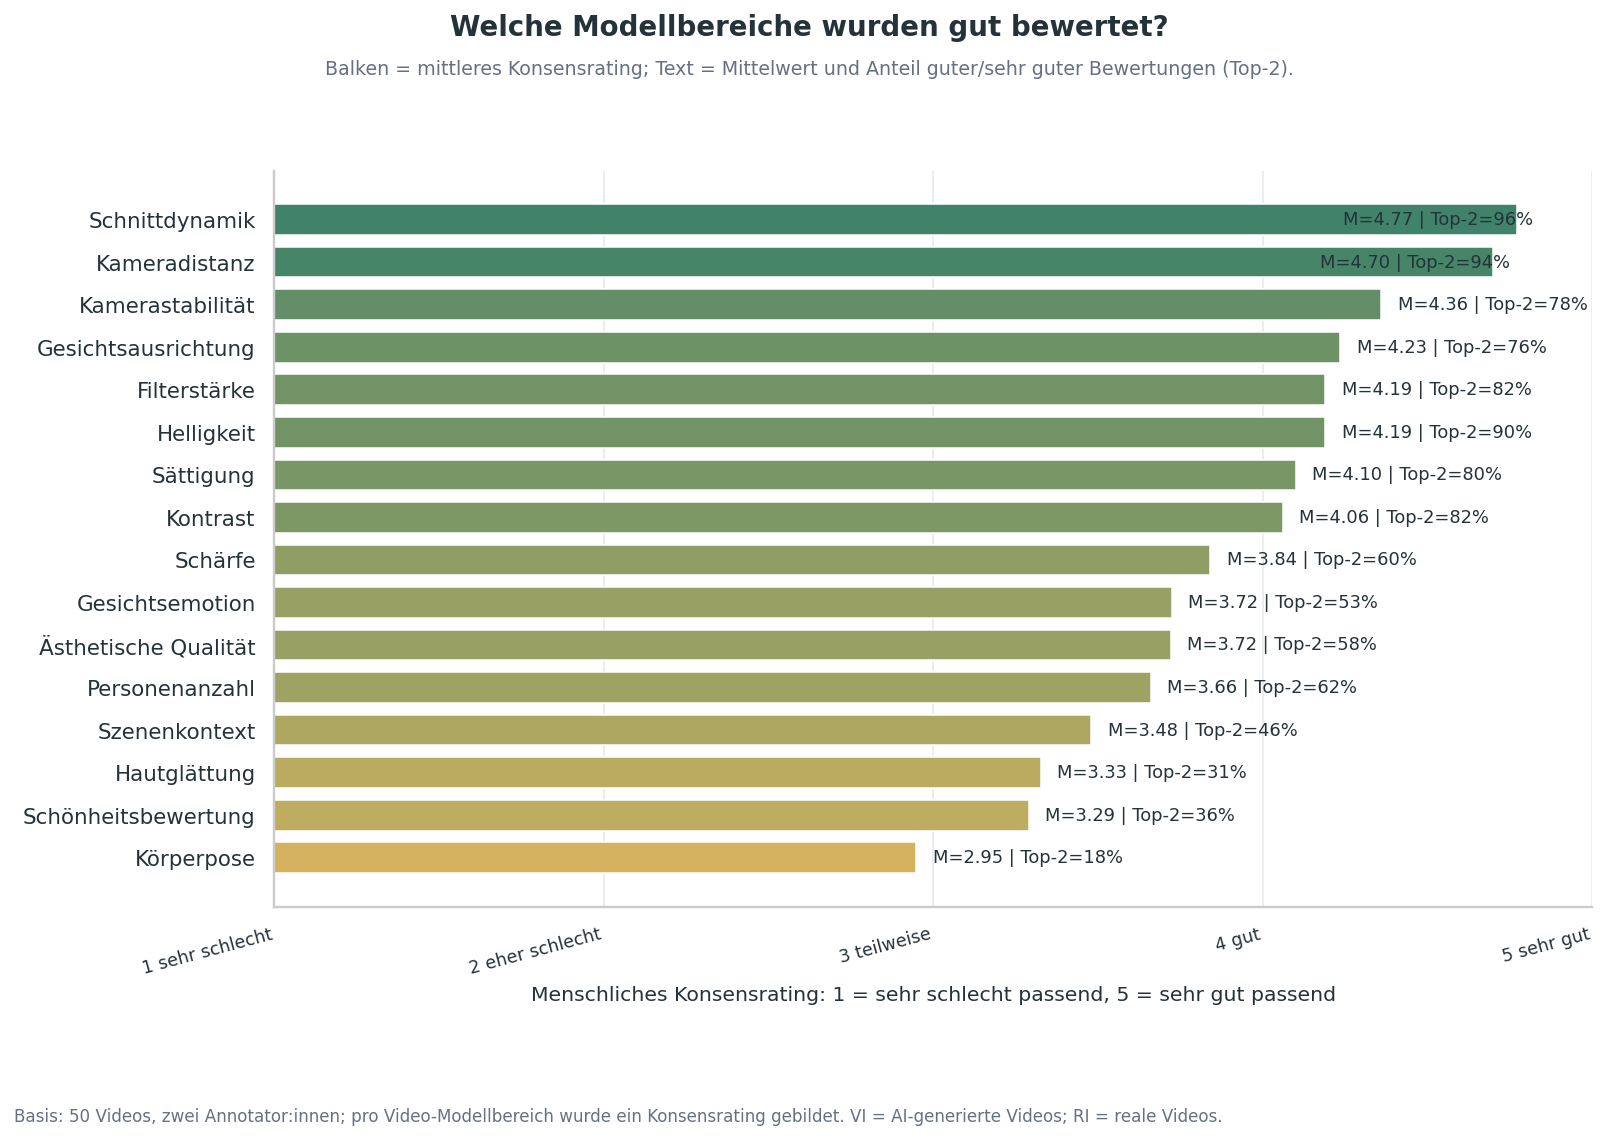

In [12]:
plot_order = (
    summary_overall_feature
    .query('is_overall == False')
    .sort_values('mean_rating', ascending=True)['feature']
    .tolist()
)

plot_summary = (
    summary_overall_feature
    .query('is_overall == False')
    .set_index('feature')
    .reindex(plot_order)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(11.6, 8.2))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')
colors = [RATING_CMAP((value - 1) / 4) if pd.notna(value) else '#DDDDDD' for value in plot_summary['mean_rating']]
ax.barh(plot_summary['feature'], plot_summary['mean_rating'], color=colors, height=0.72, edgecolor='white', linewidth=0.8)
polish_rating_axis(ax, orientation='x')
ax.set_xticklabels(['1 sehr schlecht', '2 eher schlecht', '3 teilweise', '4 gut', '5 sehr gut'], rotation=15, ha='right', fontsize=9)

for _, row in plot_summary.iterrows():
    if pd.notna(row['mean_rating']):
        label = f"M={row['mean_rating']:.2f} | Top-2={row['top2_rate']:.0%}"
        x = min(row['mean_rating'] + 0.05, 4.82)
        ha = 'left' if row['mean_rating'] < 4.65 else 'right'
        ax.text(x, row['feature'], label, va='center', ha=ha, fontsize=9.2, color=COLOR_INK)

ax.set_xlabel('Menschliches Konsensrating: 1 = sehr schlecht passend, 5 = sehr gut passend')
ax.set_ylabel('')
add_figure_header(
    fig,
    'Welche Modellbereiche wurden gut bewertet?',
    'Balken = mittleres Konsensrating; Text = Mittelwert und Anteil guter/sehr guter Bewertungen (Top-2).',
)
add_note(fig, f'Basis: 50 Videos, zwei Annotator:innen; pro Video-Modellbereich wurde ein Konsensrating gebildet. {SAMPLE_LABEL_NOTE}.', y=0.006)
plt.tight_layout(rect=(0, 0.09, 1, 0.86))
plt.show()


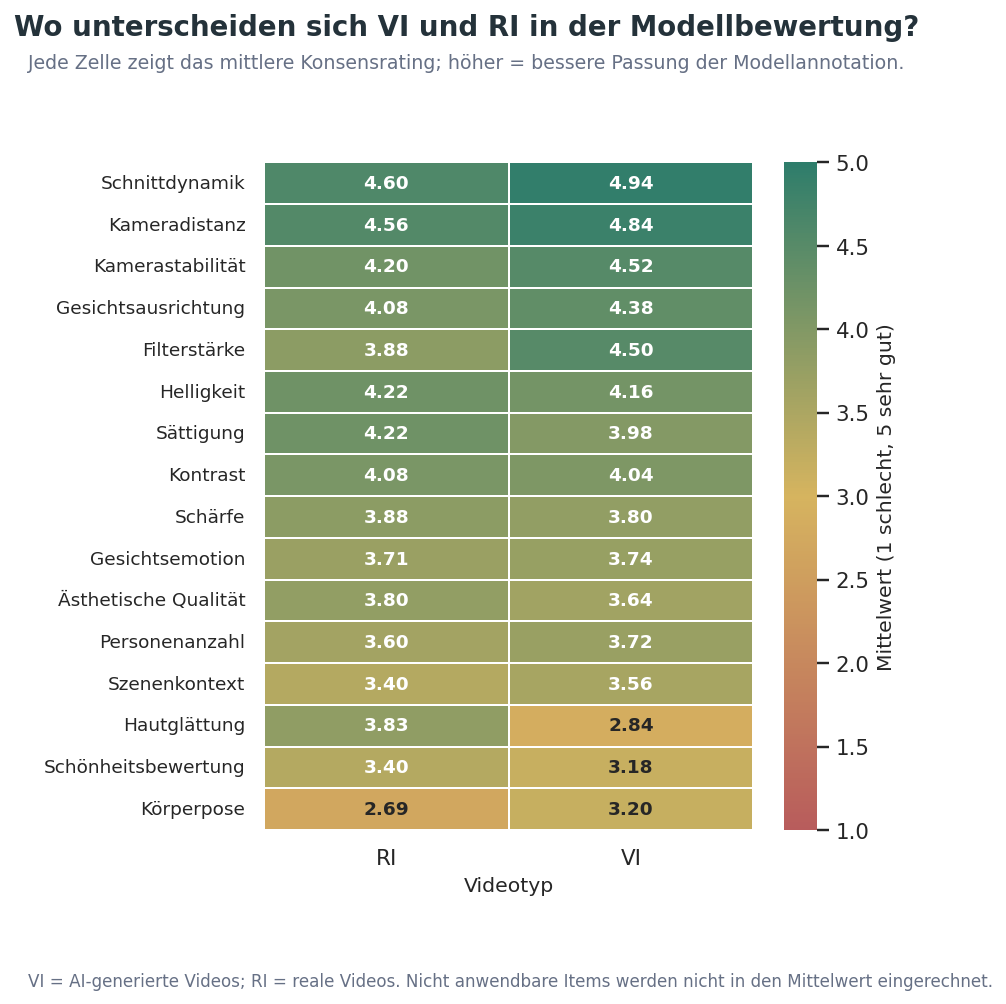

In [13]:
heatmap_data = (
    summary_by_sample_feature
    .query('is_overall == False')
    .pivot(index='feature', columns='sample_label', values='mean_rating')
    .reindex(plot_order[::-1])
)

fig, ax = plt.subplots(figsize=(6.4, 7.2))
fig.patch.set_facecolor('white')
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt='.2f',
    cmap=RATING_CMAP,
    vmin=1,
    vmax=5,
    linewidths=1.0,
    linecolor='white',
    cbar_kws={'label': 'Mittelwert (1 schlecht, 5 sehr gut)'},
    annot_kws={'fontsize': 9.5, 'fontweight': 'bold'},
    ax=ax,
)
ax.set_xlabel('Videotyp')
ax.set_ylabel('')
ax.tick_params(axis='x', rotation=0)
ax.tick_params(axis='y', labelsize=9.5)
add_figure_header(
    fig,
    'Wo unterscheiden sich VI und RI in der Modellbewertung?',
    'Jede Zelle zeigt das mittlere Konsensrating; höher = bessere Passung der Modellannotation.',
)
add_note(fig, f'{SAMPLE_LABEL_NOTE}. Nicht anwendbare Items werden nicht in den Mittelwert eingerechnet.', y=0.006)
plt.tight_layout(rect=(0, 0.075, 1, 0.86))
plt.show()


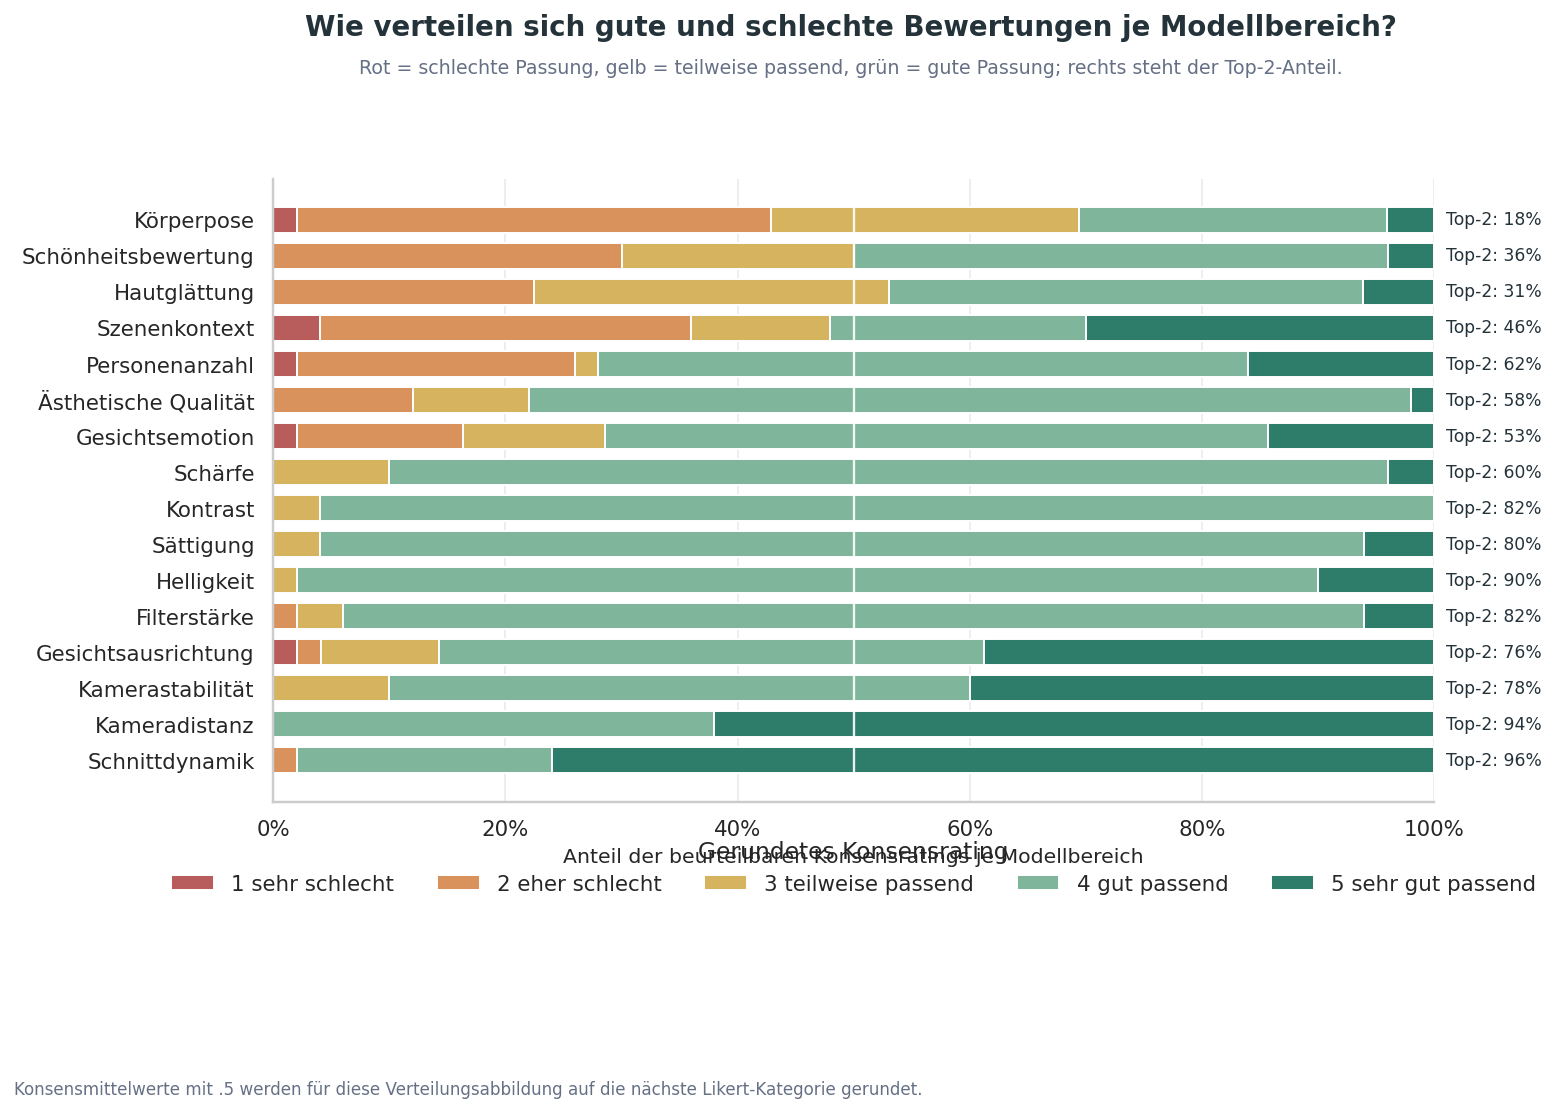

In [14]:
distribution = (
    consensus_df[consensus_df['consensus_rating'].notna() & ~consensus_df['is_overall']]
    .assign(rating_int=lambda d: d['consensus_rating'].round().astype(int).clip(1, 5))
    .groupby(['feature', 'rating_int'], observed=True)
    .size()
    .rename('n')
    .reset_index()
)

all_index = pd.MultiIndex.from_product([plot_order[::-1], LIKERT_LEVELS], names=['feature', 'rating_int'])
distribution = distribution.set_index(['feature', 'rating_int']).reindex(all_index, fill_value=0).reset_index()
distribution['share'] = distribution.groupby('feature', observed=True)['n'].transform(lambda s: s / s.sum() if s.sum() else np.nan)

fig, ax = plt.subplots(figsize=(12.2, 8.0))
fig.patch.set_facecolor('white')
y = np.arange(len(plot_order[::-1]))
left = np.zeros(len(y))
for rating in LIKERT_LEVELS:
    vals = (
        distribution[distribution['rating_int'] == rating]
        .set_index('feature')
        .reindex(plot_order[::-1])['share']
        .fillna(0)
        .to_numpy()
    )
    ax.barh(y, vals, left=left, color=PALETTE_LIKERT[rating], label=LIKERT_LABELS[rating], height=0.72)
    left += vals

ax.set_yticks(y)
ax.set_yticklabels(plot_order[::-1])
ax.set_xlim(0, 1)
ax.xaxis.set_major_formatter(PercentFormatter(1.0))
ax.set_xlabel('Anteil der beurteilbaren Konsensratings je Modellbereich')
ax.set_ylabel('')
ax.axvline(0.5, color='white', linewidth=1.2, alpha=0.9)
ax.set_facecolor('white')
ax.grid(True, axis='x', color=COLOR_GRID)
ax.grid(False, axis='y')
ax.legend(loc='lower center', bbox_to_anchor=(0.5, -0.18), ncol=5, title='Gerundetes Konsensrating')

top2_lookup = summary_overall_feature.set_index('feature')['top2_rate']
for yi, feature in enumerate(plot_order[::-1]):
    ax.text(1.01, yi, f"Top-2: {top2_lookup[feature]:.0%}", va='center', ha='left', fontsize=8.8, color=COLOR_INK)

add_figure_header(
    fig,
    'Wie verteilen sich gute und schlechte Bewertungen je Modellbereich?',
    'Rot = schlechte Passung, gelb = teilweise passend, grün = gute Passung; rechts steht der Top-2-Anteil.',
)
add_note(fig, 'Konsensmittelwerte mit .5 werden für diese Verteilungsabbildung auf die nächste Likert-Kategorie gerundet.', y=0.006)
plt.tight_layout(rect=(0, 0.12, 0.92, 0.85))
plt.show()


## Reliabilitätsplot

Diese Abbildung zeigt, für welche Modellbereiche die menschliche Bewertung besonders stabil war. Inhaltlich sollten Modellqualitätsbefunde aus Bereichen mit schwacher Reliabilität zurückhaltender interpretiert werden.

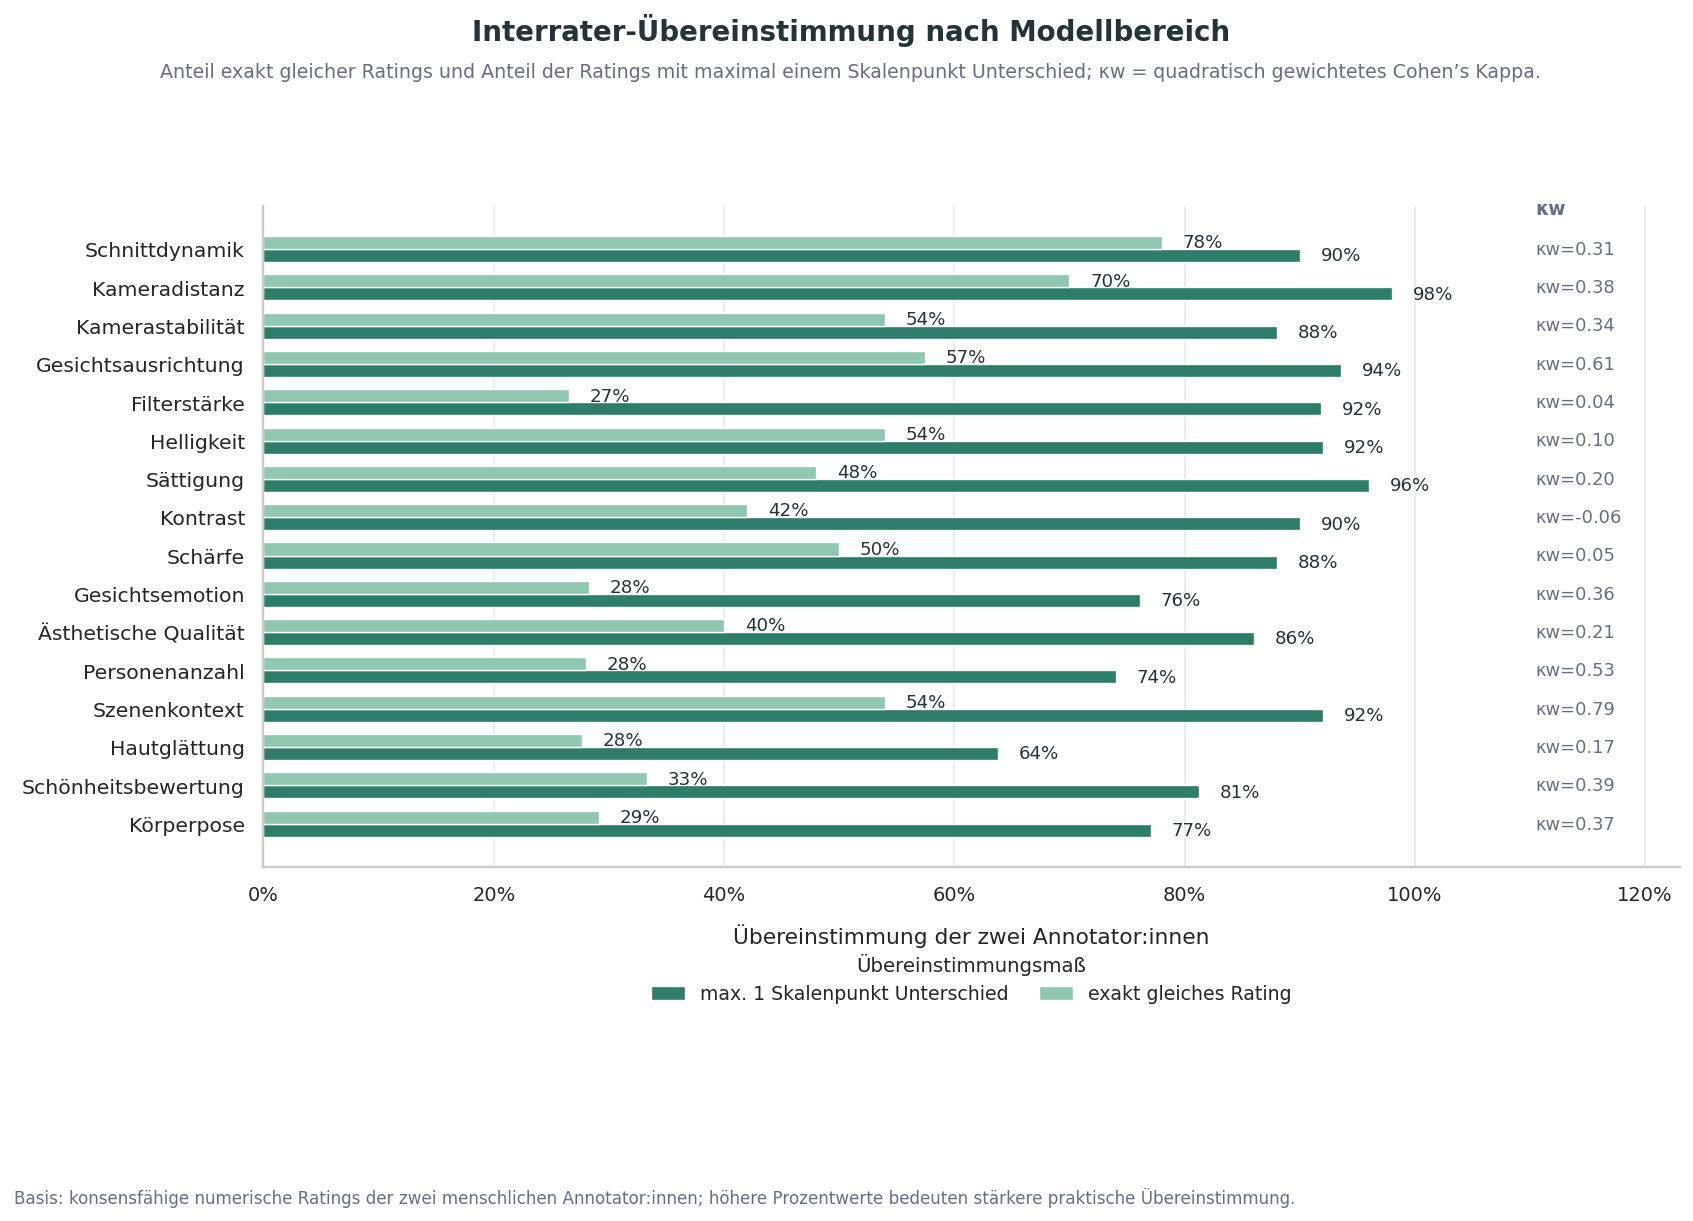

In [15]:
reliability_plot = (
    reliability_overall_feature
    .query('is_overall == False')
    .set_index('feature')
    .reindex(plot_order)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(12.2, 8.8))
fig.patch.set_facecolor('white')
y = np.arange(len(reliability_plot))
bar_height = 0.34

ax.barh(
    y - bar_height / 2,
    reliability_plot['within_one_agreement'],
    height=bar_height,
    color='#2E7D6B',
    label='max. 1 Skalenpunkt Unterschied',
    edgecolor='white',
    linewidth=0.7,
)
ax.barh(
    y + bar_height / 2,
    reliability_plot['exact_agreement'],
    height=bar_height,
    color='#8FC7B1',
    label='exakt gleiches Rating',
    edgecolor='white',
    linewidth=0.7,
)

ax.set_yticks(y)
ax.set_yticklabels(reliability_plot['feature'], fontsize=10.5)
ax.set_xlim(0, 1.23)
ax.xaxis.set_major_formatter(PercentFormatter(1.0))
ax.tick_params(axis='x', labelsize=10)
ax.set_xlabel('Übereinstimmung der zwei Annotator:innen', fontsize=11.2, labelpad=10)
ax.set_ylabel('')
ax.set_facecolor('white')
ax.grid(True, axis='x', color=COLOR_GRID)
ax.grid(False, axis='y')
sns.despine(ax=ax)

for yi, row in enumerate(reliability_plot.itertuples()):
    ax.text(
        min(row.within_one_agreement + 0.018, 1.04),
        yi - bar_height / 2,
        f"{row.within_one_agreement:.0%}",
        va='center',
        ha='left',
        fontsize=9.4,
        color=COLOR_INK,
    )
    ax.text(
        min(row.exact_agreement + 0.018, 1.04),
        yi + bar_height / 2,
        f"{row.exact_agreement:.0%}",
        va='center',
        ha='left',
        fontsize=9.4,
        color=COLOR_INK,
    )
    ax.text(
        1.105,
        yi,
        f"κw={row.weighted_kappa_quadratic:.2f}",
        va='center',
        ha='left',
        fontsize=9.2,
        color=COLOR_MUTED,
    )

ax.text(1.105, len(reliability_plot) - 0.2, 'κw', ha='left', va='bottom', fontsize=9.6, fontweight='bold', color=COLOR_MUTED)
ax.legend(
    loc='upper center',
    bbox_to_anchor=(0.50, -0.105),
    ncol=2,
    title='Übereinstimmungsmaß',
    fontsize=9.7,
    title_fontsize=10.2,
    columnspacing=1.6,
    handlelength=1.8,
)

add_figure_header(
    fig,
    'Interrater-Übereinstimmung nach Modellbereich',
    'Anteil exakt gleicher Ratings und Anteil der Ratings mit maximal einem Skalenpunkt Unterschied; κw = quadratisch gewichtetes Cohen’s Kappa.',
)
add_note(fig, 'Basis: konsensfähige numerische Ratings der zwei menschlichen Annotator:innen; höhere Prozentwerte bedeuten stärkere praktische Übereinstimmung.', y=0.006)
plt.tight_layout(rect=(0, 0.12, 1, 0.84))
plt.show()


## Gesamturteil pro Video

Neben `eval_overall_model_quality` ist der Durchschnitt über alle bereichsspezifischen Konsensratings pro Video hilfreich. Dadurch sieht man, ob das explizite Gesamturteil und die Detailbewertungen ungefaehr dieselbe Geschichte erzählen.

In [16]:
feature_scores_wide = (
    consensus_df[~consensus_df['is_overall']]
    .pivot_table(
        index=['sample_type', 'sample_label', 'video_id', '_video_stem'],
        columns='eval_column',
        values='consensus_rating',
        aggfunc='first',
    )
    .reset_index()
)
feature_scores_wide['mean_feature_rating'] = feature_scores_wide[feature_eval_cols].mean(axis=1, skipna=True)

overall_scores = (
    consensus_df[consensus_df['eval_column'] == 'eval_overall_model_quality']
    [['sample_type', 'sample_label', 'video_id', 'consensus_rating']]
    .rename(columns={'consensus_rating': 'overall_model_quality_rating'})
)
video_quality = feature_scores_wide.merge(overall_scores, on=['sample_type', 'sample_label', 'video_id'], how='left')

video_quality[['sample_type', 'video_id', 'mean_feature_rating', 'overall_model_quality_rating']].head()


,sample_type,video_id,mean_feature_rating,overall_model_quality_rating
0,AI,6988896764241693958,3.62500,3.0
1,AI,7014189798315298053,3.65625,3.0
2,AI,7027954993026190598,3.93750,3.0
3,AI,7032242293411286273,4.06250,4.0
4,AI,7034987201482001670,3.90625,3.5


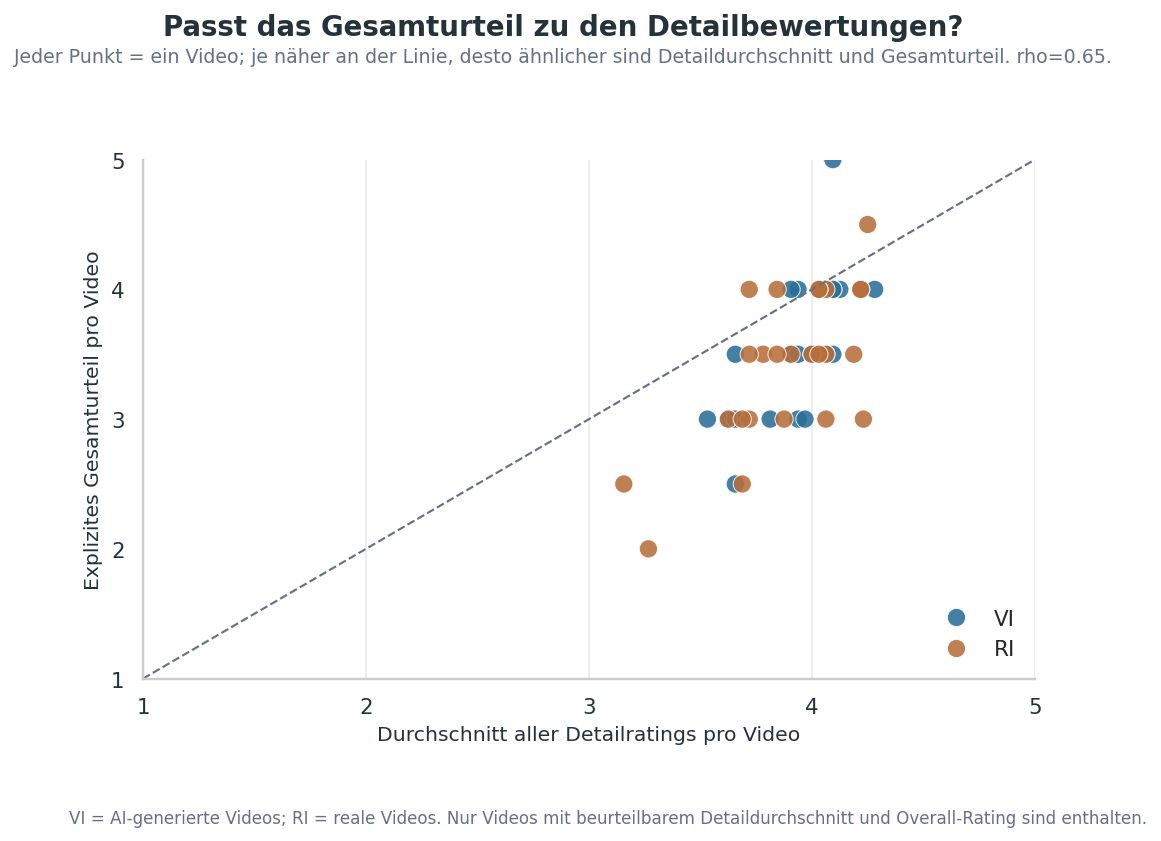

Spearman correlation between mean detail rating and explicit overall rating: 0.65


In [17]:
fig, ax = plt.subplots(figsize=(7.2, 6.0))
fig.patch.set_facecolor('white')
plot_data = video_quality.dropna(subset=['mean_feature_rating', 'overall_model_quality_rating'])
sns.scatterplot(
    data=plot_data,
    x='mean_feature_rating',
    y='overall_model_quality_rating',
    hue='sample_label',
    palette=PALETTE_SAMPLE_LABELS,
    s=88,
    alpha=0.88,
    edgecolor='white',
    linewidth=0.5,
    ax=ax,
)
ax.plot([1, 5], [1, 5], color=COLOR_MUTED, linestyle='--', linewidth=1.1)
polish_rating_axis(ax, orientation='x')
polish_rating_axis(ax, orientation='y')
ax.set_xlabel('Durchschnitt aller Detailratings pro Video')
ax.set_ylabel('Explizites Gesamturteil pro Video')
ax.legend(title='', loc='lower right')

correlation = plot_data[['mean_feature_rating', 'overall_model_quality_rating']].corr(method='spearman').iloc[0, 1]
add_figure_header(
    fig,
    'Passt das Gesamturteil zu den Detailbewertungen?',
    f'Jeder Punkt = ein Video; je näher an der Linie, desto ähnlicher sind Detaildurchschnitt und Gesamturteil. rho={correlation:.2f}.',
)
add_note(fig, f'{SAMPLE_LABEL_NOTE}. Nur Videos mit beurteilbarem Detaildurchschnitt und Overall-Rating sind enthalten.', y=0.006)
plt.tight_layout(rect=(0, 0.075, 1, 0.84))
plt.show()

print(f'Spearman correlation between mean detail rating and explicit overall rating: {correlation:.2f}')


## Top- und Low-Performer

Diese Tabellen sind praktisch für die Ergebnisinterpretation: oben stehen die Modellbereiche, die laut konsensbasierter Human Evaluation am zuverlaessigsten passen; unten die Bereiche, die am ehesten Nacharbeit brauchen. Die Reliabilität wird direkt mit ausgegeben, damit Bewertung und Messqualität gemeinsam interpretiert werden.

In [18]:
ranked_features = (
    summary_overall_feature
    .query('is_overall == False')
    .merge(
        reliability_overall_feature[['eval_column', 'weighted_kappa_quadratic', 'exact_agreement', 'within_one_agreement']],
        on='eval_column',
        how='left',
    )
    .sort_values('mean_rating', ascending=False)
    .assign(
        mean_rating=lambda d: d['mean_rating'].round(2),
        top2_rate=lambda d: d['top2_rate'].round(2),
        low2_rate=lambda d: d['low2_rate'].round(2),
        applicability_rate=lambda d: d['applicability_rate'].round(2),
        sd_rating=lambda d: d['sd_rating'].round(2),
        weighted_kappa_quadratic=lambda d: d['weighted_kappa_quadratic'].round(2),
        exact_agreement=lambda d: d['exact_agreement'].round(2),
        within_one_agreement=lambda d: d['within_one_agreement'].round(2),
    )
    [[
        'feature_group', 'feature', 'n_rated_items', 'n_not_applicable_items', 'applicability_rate',
        'mean_rating', 'median_rating', 'top2_rate', 'low2_rate', 'sd_rating',
        'weighted_kappa_quadratic', 'exact_agreement', 'within_one_agreement',
    ]]
)

print('Best bewertet:')
display(ranked_features.head(8))

print('Kritischste Bereiche:')
display(ranked_features.tail(8).sort_values('mean_rating'))


Best bewertet:


,feature_group,feature,n_rated_items,n_not_applicable_items,applicability_rate,mean_rating,median_rating,top2_rate,low2_rate,sd_rating,weighted_kappa_quadratic,exact_agreement,within_one_agreement
7,Kamera & Schnitt,Schnittdynamik,50,0,1.00,4.77,5.0,0.96,0.02,0.54,0.31,0.78,0.90
4,Kamera & Schnitt,Kameradistanz,50,0,1.00,4.70,5.0,0.94,0.00,0.45,0.38,0.70,0.98
5,Kamera & Schnitt,Kamerastabilität,50,0,1.00,4.36,4.5,0.78,0.00,0.69,0.34,0.54,0.88
9,Inhalt & Semantik,Gesichtsausrichtung,49,1,0.98,4.23,4.5,0.76,0.04,0.92,0.61,0.57,0.94
3,Bildqualität,Helligkeit,50,0,1.00,4.19,4.0,0.90,0.00,0.43,0.10,0.54,0.92
10,Visuelle Wirkung,Filterstärke,50,0,1.00,4.19,4.5,0.82,0.00,0.52,0.04,0.27,0.92
12,Bildqualität,Sättigung,50,0,1.00,4.10,4.0,0.80,0.00,0.46,0.20,0.48,0.96
6,Bildqualität,Kontrast,50,0,1.00,4.06,4.0,0.82,0.00,0.40,-0.06,0.42,0.90


Kritischste Bereiche:


,feature_group,feature,n_rated_items,n_not_applicable_items,applicability_rate,mean_rating,median_rating,top2_rate,low2_rate,sd_rating,weighted_kappa_quadratic,exact_agreement,within_one_agreement
2,Inhalt & Semantik,Körperpose,49,1,0.98,2.95,3.00,0.18,0.22,0.99,0.37,0.29,0.77
1,Visuelle Wirkung,Schönheitsbewertung,50,0,1.00,3.29,3.25,0.36,0.10,0.89,0.39,0.33,0.81
15,Visuelle Wirkung,Hautglättung,49,1,0.98,3.33,3.00,0.31,0.04,0.74,0.17,0.28,0.64
13,Inhalt & Semantik,Szenenkontext,50,0,1.00,3.48,3.50,0.46,0.18,1.31,0.79,0.54,0.92
11,Inhalt & Semantik,Personenanzahl,50,0,1.00,3.66,4.00,0.62,0.20,1.20,0.53,0.28,0.74
8,Inhalt & Semantik,Gesichtsemotion,49,1,0.98,3.72,4.00,0.53,0.04,0.91,0.36,0.28,0.76
0,Visuelle Wirkung,Ästhetische Qualität,50,0,1.00,3.72,4.00,0.58,0.00,0.64,0.21,0.40,0.86
14,Bildqualität,Schärfe,50,0,1.00,3.84,4.00,0.60,0.00,0.47,0.05,0.50,0.88


## AI-vs-REAL Differenzen mit Bootstrap-CI

Die Differenzen werden auf Basis der Konsensratings berechnet. Positive Werte bedeuten: AI-generierte Videos wurden im Mittel besser bewertet als reale Videos. Bei `n=25` pro Gruppe sind die Intervalle deskriptiv zu interpretieren.

In [19]:
def bootstrap_mean_diff(ai_values, real_values, n_boot=5000, seed=RANDOM_SEED):
    ai_values = np.asarray(pd.Series(ai_values).dropna(), dtype=float)
    real_values = np.asarray(pd.Series(real_values).dropna(), dtype=float)
    if len(ai_values) == 0 or len(real_values) == 0:
        return pd.Series({'mean_diff_ai_minus_real': np.nan, 'ci_low': np.nan, 'ci_high': np.nan})
    rng = np.random.default_rng(seed)
    diffs = np.empty(n_boot)
    for i in range(n_boot):
        ai_sample = rng.choice(ai_values, size=len(ai_values), replace=True)
        real_sample = rng.choice(real_values, size=len(real_values), replace=True)
        diffs[i] = ai_sample.mean() - real_sample.mean()
    return pd.Series({
        'mean_diff_ai_minus_real': ai_values.mean() - real_values.mean(),
        'ci_low': np.quantile(diffs, 0.025),
        'ci_high': np.quantile(diffs, 0.975),
    })


diff_rows = []
for eval_col in eval_cols:
    part = consensus_df[consensus_df['eval_column'] == eval_col]
    result = bootstrap_mean_diff(
        part.loc[part['sample_type'] == 'AI', 'consensus_rating'],
        part.loc[part['sample_type'] == 'REAL', 'consensus_rating'],
    )
    diff_rows.append({
        'eval_column': eval_col,
        'feature': FEATURE_LABELS.get(eval_col, eval_col),
        'is_overall': eval_col == 'eval_overall_model_quality',
        **result.to_dict(),
    })

diff_summary = pd.DataFrame(diff_rows).sort_values('mean_diff_ai_minus_real', ascending=False)
diff_summary.assign(
    mean_diff_ai_minus_real=lambda d: d['mean_diff_ai_minus_real'].round(2),
    ci_low=lambda d: d['ci_low'].round(2),
    ci_high=lambda d: d['ci_high'].round(2),
)


,eval_column,feature,is_overall,mean_diff_ai_minus_real,ci_low,ci_high
10,eval_filter_strength,Filterstärke,False,0.62,0.40,0.86
2,eval_body_pose,Körperpose,False,0.51,-0.02,1.04
7,eval_cuts_dynamik,Schnittdynamik,False,0.34,0.08,0.64
5,eval_camera_stability,Kamerastabilität,False,0.32,-0.06,0.68
9,eval_face_orientation,Gesichtsausrichtung,False,0.30,-0.18,0.81
4,eval_camera_distance,Kameradistanz,False,0.28,0.06,0.52
11,eval_overall_model_quality,Gesamtqualität der Modellannotation,True,0.18,-0.12,0.50
14,eval_scene_context,Szenenkontext,False,0.16,-0.58,0.86
12,eval_personen_anzahl,Personenanzahl,False,0.12,-0.52,0.78
8,eval_face_emotion,Gesichtsemotion,False,0.03,-0.46,0.52


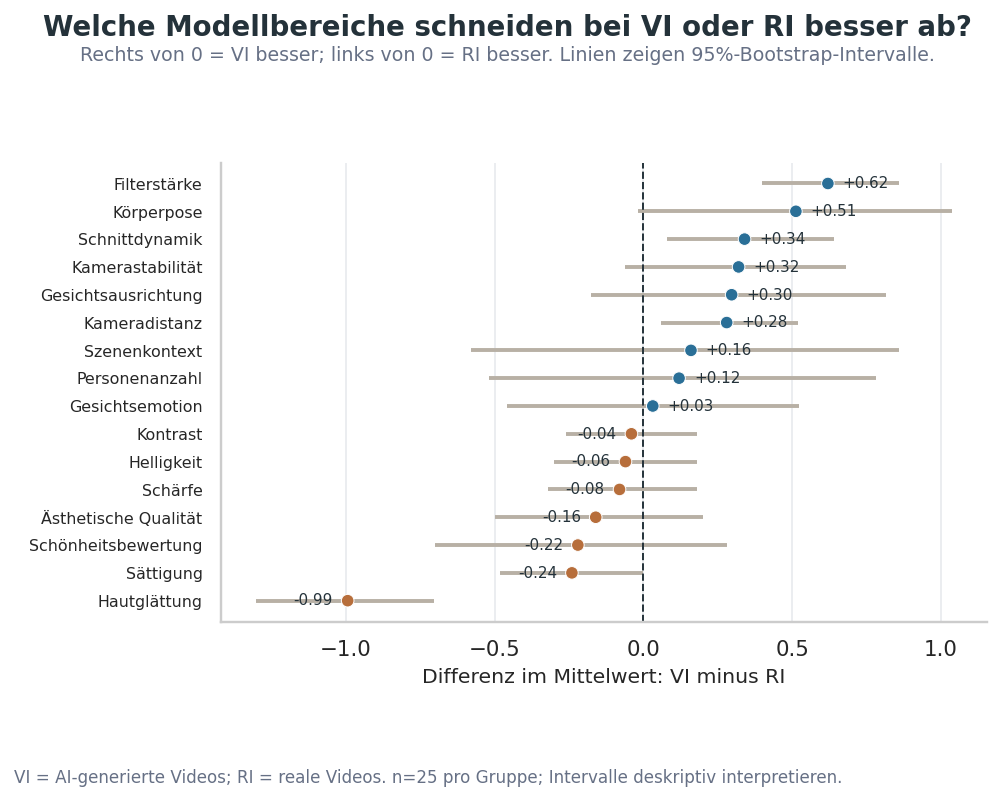

In [20]:
diff_plot = diff_summary.query('is_overall == False').copy().sort_values('mean_diff_ai_minus_real')

fig, ax = plt.subplots(figsize=(7.2, 5.7))
fig.patch.set_facecolor('white')
y = np.arange(len(diff_plot))
ax.hlines(y=y, xmin=diff_plot['ci_low'], xmax=diff_plot['ci_high'], color='#B8B0A5', linewidth=2.0)
colors = np.where(diff_plot['mean_diff_ai_minus_real'] >= 0, COLOR_AI, COLOR_REAL)
ax.scatter(diff_plot['mean_diff_ai_minus_real'], y, c=colors, s=42, zorder=3, edgecolor='white', linewidth=0.5)
ax.axvline(0, color=COLOR_INK, linestyle='--', linewidth=1)
ax.set_yticks(y)
ax.set_yticklabels(diff_plot['feature'], fontsize=8.2)
ax.set_xlabel('Differenz im Mittelwert: VI minus RI')
ax.set_ylabel('')
ax.set_facecolor('white')
ax.grid(True, axis='x', color=COLOR_GRID)
ax.grid(False, axis='y')

for yi, row in enumerate(diff_plot.itertuples()):
    x = row.mean_diff_ai_minus_real
    ax.text(x + (0.05 if x >= 0 else -0.05), yi, f"{x:+.2f}", va='center', ha='left' if x >= 0 else 'right', fontsize=7.8, color=COLOR_INK)

add_figure_header(
    fig,
    'Welche Modellbereiche schneiden bei VI oder RI besser ab?',
    'Rechts von 0 = VI besser; links von 0 = RI besser. Linien zeigen 95%-Bootstrap-Intervalle.',
)
add_note(fig, f'{SAMPLE_LABEL_NOTE}. n=25 pro Gruppe; Intervalle deskriptiv interpretieren.', y=0.006)
plt.tight_layout(rect=(0, 0.10, 1, 0.82))
plt.show()


## Qualitätsprofil nach Modellgruppen

Die einzelnen Modellbereiche werden zusätzlich in grobe Gruppen gebuendelt. Das ist nützlich für die Ergebnisdiskussion, weil z.B. Bildqualitätsmodelle anders funktionieren als semantische Inhaltsmodelle.

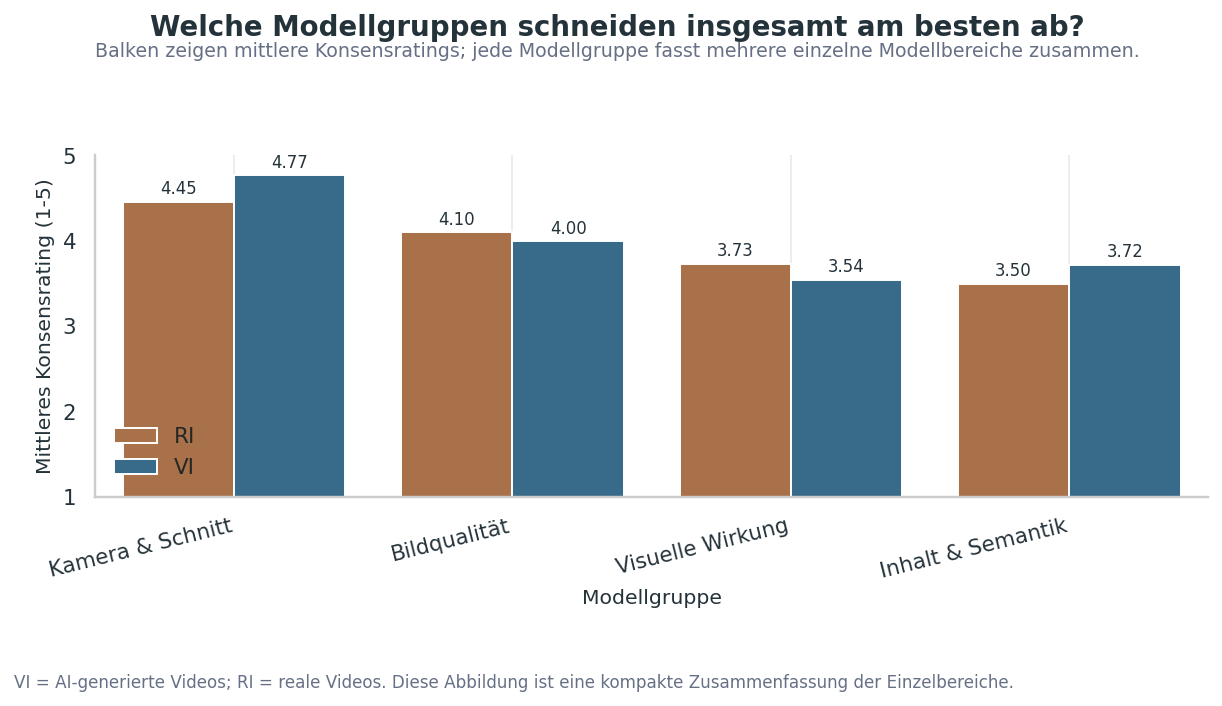

,sample_label,feature_group,n_rated_items,mean_rating,top2_rate,low2_rate
0,RI,Bildqualität,100,4.10,0.83,0.00
1,RI,Inhalt & Semantik,122,3.50,0.48,0.16
2,RI,Kamera & Schnitt,75,4.45,0.84,0.01
3,RI,Visuelle Wirkung,99,3.73,0.58,0.00
4,VI,Bildqualität,100,4.00,0.73,0.00
5,VI,Inhalt & Semantik,125,3.72,0.54,0.11
6,VI,Kamera & Schnitt,75,4.77,0.95,0.00
7,VI,Visuelle Wirkung,100,3.54,0.46,0.07


In [21]:
group_summary = (
    consensus_df[~consensus_df['is_overall']]
    .groupby(['sample_label', 'feature_group'], observed=True)
    .agg(
        n_rated_items=('consensus_rating', lambda s: int(s.notna().sum())),
        mean_rating=('consensus_rating', 'mean'),
        top2_rate=('consensus_rating', lambda s: share_among_rated(s, lambda x: x.ge(4))),
        low2_rate=('consensus_rating', lambda s: share_among_rated(s, lambda x: x.le(2))),
    )
    .reset_index()
)

group_order = group_summary.groupby('feature_group', observed=True)['mean_rating'].mean().sort_values(ascending=False).index.tolist()

fig, ax = plt.subplots(figsize=(8.8, 5.0))
fig.patch.set_facecolor('white')
sns.barplot(
    data=group_summary,
    x='feature_group',
    y='mean_rating',
    hue='sample_label',
    order=group_order,
    palette=PALETTE_SAMPLE_LABELS,
    errorbar=None,
    ax=ax,
)
polish_rating_axis(ax, orientation='y')
ax.set_xlabel('Modellgruppe')
ax.set_ylabel('Mittleres Konsensrating (1-5)')
ax.legend(title='', loc='lower left')
plt.xticks(rotation=14, ha='right')

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=2, fontsize=8.5, color=COLOR_INK)

add_figure_header(
    fig,
    'Welche Modellgruppen schneiden insgesamt am besten ab?',
    'Balken zeigen mittlere Konsensratings; jede Modellgruppe fasst mehrere einzelne Modellbereiche zusammen.',
)
add_note(fig, f'{SAMPLE_LABEL_NOTE}. Diese Abbildung ist eine kompakte Zusammenfassung der Einzelbereiche.', y=0.006)
plt.tight_layout(rect=(0, 0.09, 1, 0.82))
plt.show()

group_summary.assign(
    mean_rating=lambda d: d['mean_rating'].round(2),
    top2_rate=lambda d: d['top2_rate'].round(2),
    low2_rate=lambda d: d['low2_rate'].round(2),
)


## Export der Ergebnisdaten

Die wichtigsten Tabellen werden als CSV im Ordner `data/04_analysis_results/human_evaluation` gespeichert. Die Exporte trennen Rohformat, gepaarte Annotator:innenwerte, Reliabilität und konsensbasierte Modellbewertung.

In [22]:
long_df.to_csv(OUTPUT_DIR / 'human_eval_long_annotator_ratings.csv', index=False)
paired_df.to_csv(OUTPUT_DIR / 'human_eval_paired_annotator_ratings.csv', index=False)
consensus_df.to_csv(OUTPUT_DIR / 'human_eval_consensus_item_ratings.csv', index=False)
annotator_summary.to_csv(OUTPUT_DIR / 'human_eval_annotator_summary.csv', index=False)
reliability_by_sample_feature.to_csv(OUTPUT_DIR / 'human_eval_reliability_by_sample_feature.csv', index=False)
reliability_overall_feature.to_csv(OUTPUT_DIR / 'human_eval_reliability_overall_feature.csv', index=False)
summary_by_sample_feature.to_csv(OUTPUT_DIR / 'human_eval_consensus_summary_by_sample_feature.csv', index=False)
summary_overall_feature.to_csv(OUTPUT_DIR / 'human_eval_consensus_summary_overall_feature.csv', index=False)
diff_summary.to_csv(OUTPUT_DIR / 'human_eval_ai_vs_real_bootstrap_diff.csv', index=False)
video_quality.to_csv(OUTPUT_DIR / 'human_eval_video_quality_scores.csv', index=False)

generated_files = sorted(p.name for p in OUTPUT_DIR.glob('human_eval_*.csv'))
print('Saved result tables to:', OUTPUT_DIR.resolve())
for name in generated_files:
    print('-', name)


Saved result tables to: /Users/hannahernstberger/Documents/Master_/data/04_analysis_results/human_evaluation
- human_eval_ai_vs_real_bootstrap_diff.csv
- human_eval_annotator_summary.csv
- human_eval_consensus_item_ratings.csv
- human_eval_consensus_summary_by_sample_feature.csv
- human_eval_consensus_summary_overall_feature.csv
- human_eval_long_annotator_ratings.csv
- human_eval_paired_annotator_ratings.csv
- human_eval_reliability_by_sample_feature.csv
- human_eval_reliability_overall_feature.csv
- human_eval_video_quality_scores.csv


## Kurze Interpretationshilfe

- Die Reliabilität sollte vor der Modellqualität berichtet werden, weil schwache Übereinstimmung die Aussagekraft der Human Evaluation begrenzt.
- Für ordinale 1-5-Ratings ist quadratisch gewichtetes Kappa zentral; Exact Agreement und Within-1 Agreement ergänzen die Interpretation anschaulich.
- `ICC(A,2)` beschreibt, wie verlässlich der Mittelwert aus beiden Annotator:innen ist. Dieser Wert ist für die anschließende Konsensauswertung besonders relevant.
- Modellbereiche mit hohem `top2_rate`, hohem Mittelwert und akzeptabler Reliabilität sind robuste Stärken der Pipeline.
- Bereiche mit niedrigem Mittelwert oder niedriger Reliabilität sollten in der Thesis vorsichtig und differenziert diskutiert werden.
- `Unbestimmt` bedeutet: Der jeweilige Modellbereich war im Video nicht sinnvoll beurteilbar. Eine Häufung von `Unbestimmt` ist eine Applicability-Information, kein negatives Qualitätsrating.